# Earth motion module

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt


from snudd.geometry import SolarAngles

We will load the geometry module to compute zenith angles over a data taking period

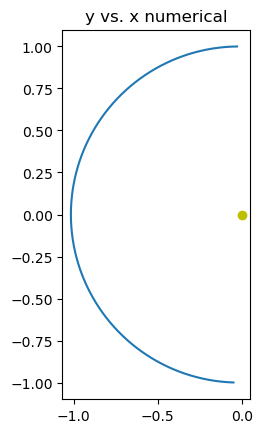

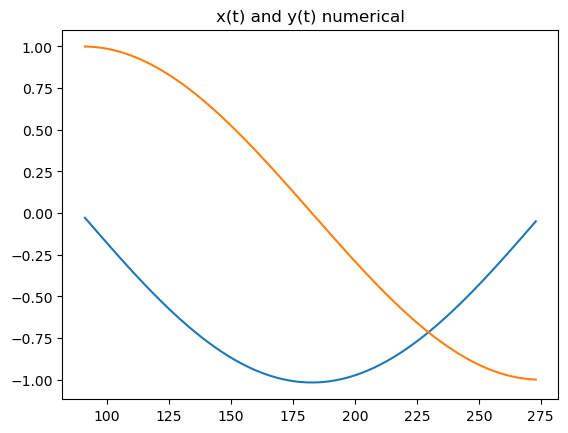

In [3]:
# Data taking period: 
# t0 - beginning in days after 3rd January (perihelion)
# T  - duration of data taking beginngin at t0 in days
t0 = 91
T  = 182

GranSasso = SolarAngles(latitude=42.47, t0=t0, T=T)

# Calculate orbital positions
times, coords = GranSasso.orbit()
x, y = coords.T[:2]
dist = np.sqrt(np.pow(x,2) + np.pow(y,2))     # Earth-Sun distance r in AU



# Plot orbit and angles
if True:
    f = plt.figure()
    # f.set_figheight(15)
    plt.subplot(1, 1, 1)
    plt.plot(x, y)
    plt.plot([0], [0], 'oy')
    plt.gca().set_aspect('equal')
    plt.title('y vs. x numerical')
    plt.show()

    plt.subplot(1, 1, 1)
    plt.plot(times, x)
    plt.plot(times, y)
    # plt.xlim(-pi, pi)
    plt.title('x(t) and y(t) numerical')

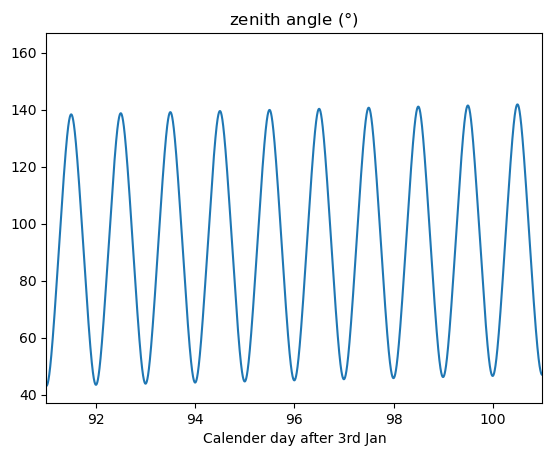

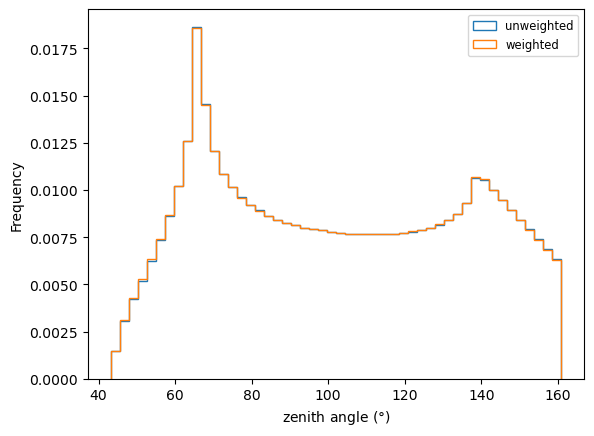

[0.75239157 0.79353284 0.83467412 0.87581539 0.91695667 0.95809795
 0.99923922 1.0403805  1.08152177 1.12266305 1.16380432 1.2049456
 1.24608688 1.28722815 1.32836943 1.3695107  1.41065198 1.45179326
 1.49293453 1.53407581 1.57521708 1.61635836 1.65749964 1.69864091
 1.73978219 1.78092346 1.82206474 1.86320601 1.90434729 1.94548857
 1.98662984 2.02777112 2.06891239 2.11005367 2.15119495 2.19233622
 2.2334775  2.27461877 2.31576005 2.35690133 2.3980426  2.43918388
 2.48032515 2.52146643 2.56260771 2.60374898 2.64489026 2.68603153
 2.72717281 2.76831408 2.80945536] [0.00344662 0.00718266 0.00983929 0.01212815 0.01459046 0.01712644
 0.02002439 0.02360424 0.02909186 0.04282365 0.03343746 0.02780147
 0.02499432 0.02336996 0.02212222 0.02119422 0.020544   0.01990538
 0.01942974 0.01903945 0.01882126 0.01845191 0.01827159 0.01812327
 0.01791113 0.01782682 0.01771535 0.01767981 0.01764344 0.01765947
 0.01769078 0.01771471 0.01786938 0.01799455 0.01819858 0.01847139
 0.0188562  0.01936588 0.020

In [4]:
# Calculate zenith angles in data taking period
times, zens = GranSasso.zenith_angles()
zens *= 180 / np.pi    # convert angles to degrees



# Plot zenith angle as a function of time
f = plt.figure()
# f.set_figheight(15)
plt.plot(times, zens)
plt.xlabel("Calender day after 3rd Jan")
plt.title(r'zenith angle ($\degree$)')
plt.xlim(t0,t0+10)
# plt.subplots_adjust(wspace=None, hspace=0.5)
plt.show()


# bin the zenith angles
ax = plt.hist(zens, density=True, bins=50, histtype='step', ls='--', label='unweighted')  # density=False would make counts
plt.hist(zens, weights=1/np.pow(dist,2), density=True, bins=50, histtype='step', label='weighted')  # density=False would make counts
plt.ylabel('Frequency')
plt.xlabel(r'zenith angle ($\degree$)')
plt.legend(fontsize='small')
# plt.text(min(zens)*0.9, 0.55, r'lat = %s$^\degree$'%latitude, ha='center', va='top')
plt.show()


angles, weights = GranSasso.zenith_hist(bins=25)
print(angles, weights)
print("Sum of weights (data taking flux/average flux):", sum(weights))